# APTOS 2019 - Diabetic Retinopathy Severity Prediction
### EfficientNet-B4 | 5-Class Classification | Quadratic Weighted Kappa

**DR Severity Scale:** 0 = No DR | 1 = Mild | 2 = Moderate | 3 = Severe | 4 = Proliferative DR

In [ ]:
!pip install -q kaggle timm albumentations

import os
import zipfile
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import pandas as pd
import numpy as np
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print(f"timm version: {timm.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128
timm version: 1.0.25


## 2. Download Dataset via Kaggle API

In [ ]:
from google.colab import files

print("Please upload your kaggle.json file:")
uploaded = files.upload()

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("\nDownloading APTOS 2019 dataset...")
!kaggle datasets download -d mariaherrerot/aptos2019 --force

print("\nExtracting files...")
with zipfile.ZipFile('aptos2019.zip', 'r') as z:
    z.extractall('aptos2019')

print("\nDone! Contents:")
!ls aptos2019/

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json

Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 8.01G/8.01G [00:31<00:00, 270MB/s]


Extracting files...

Done! Contents:
test.csv  test_images  train_1.csv  train_images  valid.csv  val_images


## 3. Exploratory Data Analysis

Train samples: 2930
Valid samples: 366

Train class distribution:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64

Detected image extension: .png


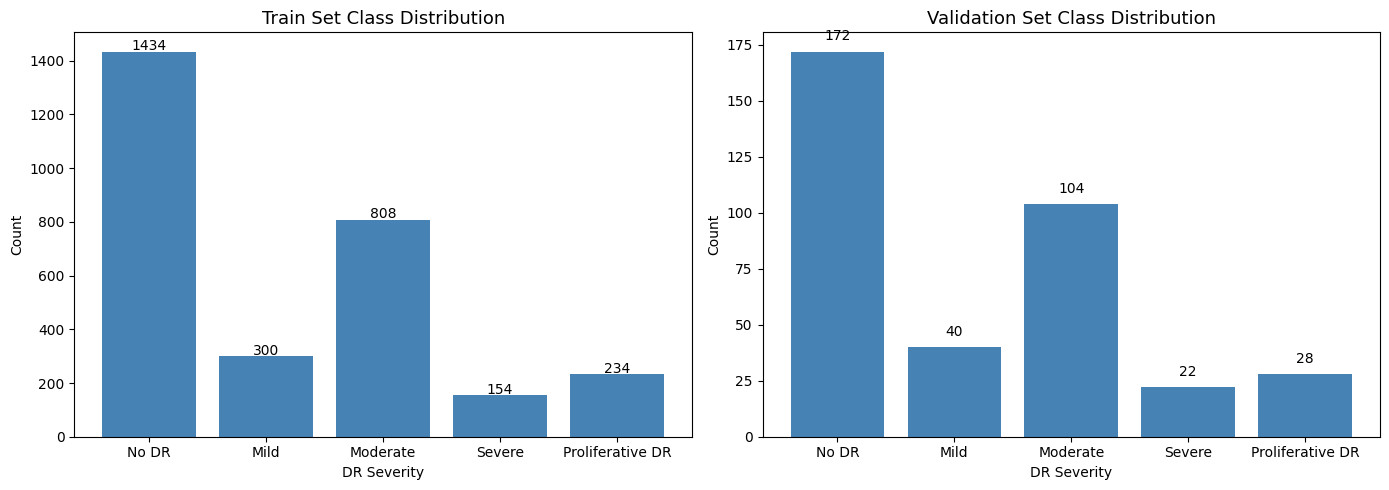

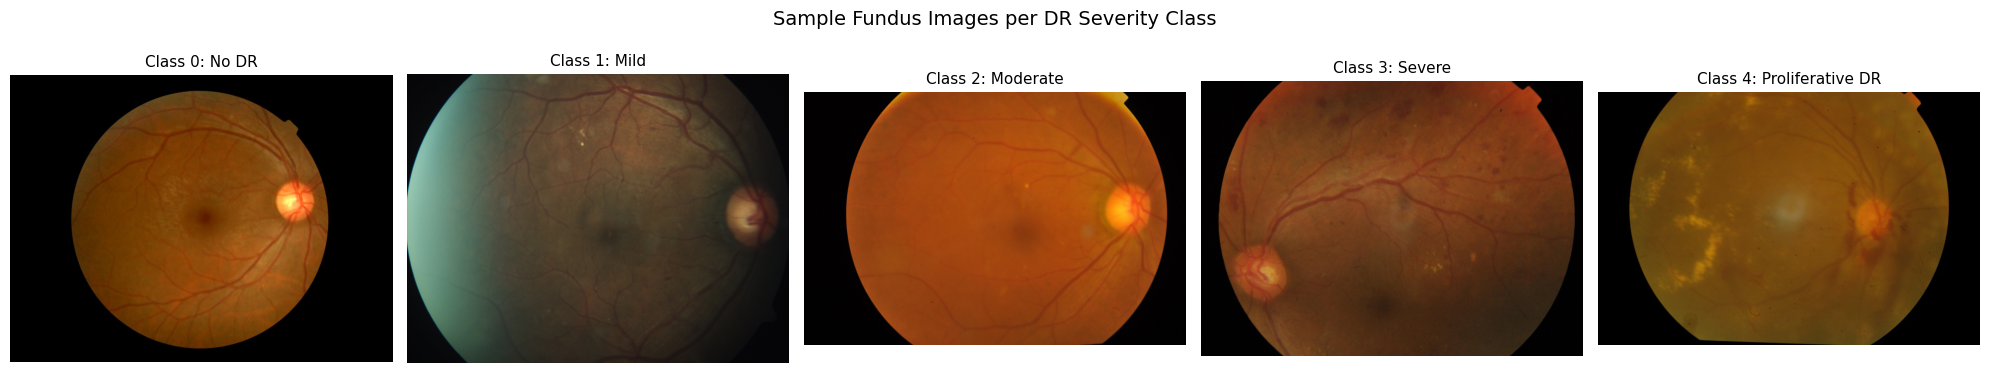

In [ ]:
DATA_DIR = 'aptos2019'
train_df = pd.read_csv(f'{DATA_DIR}/train_1.csv')
valid_df = pd.read_csv(f'{DATA_DIR}/valid.csv')

LABELS = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative DR'}

print(f"Train samples: {len(train_df)}")
print(f"Valid samples: {len(valid_df)}")
print(f"\nTrain class distribution:\n{train_df['diagnosis'].value_counts().sort_index()}")

train_img_dir = f'{DATA_DIR}/train_images/train_images'
valid_img_dir = f'{DATA_DIR}/val_images/val_images'

# Detect image extension
sample_files = [f for f in os.listdir(train_img_dir) if not f.startswith('.')][:5]
IMG_EXT = '.' + sample_files[0].split('.')[-1]
print(f"\nDetected image extension: {IMG_EXT}")

# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df, title) in zip(axes, [(train_df, 'Train'), (valid_df, 'Validation')]):
    counts = df['diagnosis'].value_counts().sort_index()
    bars = ax.bar([LABELS[i] for i in counts.index], counts.values, color='steelblue')
    ax.set_title(f'{title} Set Class Distribution', fontsize=13)
    ax.set_xlabel('DR Severity'); ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha='center', fontsize=10)
plt.tight_layout(); plt.show()

# Sample images per class
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for cls in range(5):
    sample = train_df[train_df['diagnosis'] == cls].iloc[0]['id_code']
    img_path = None
    for ext in [IMG_EXT, '.png', '.jpg', '.jpeg']:
        candidate = f'{train_img_dir}/{sample}{ext}'
        if os.path.exists(candidate):
            img_path = candidate
            break
    axes[cls].imshow(Image.open(img_path))
    axes[cls].set_title(f'Class {cls}: {LABELS[cls]}', fontsize=11)
    axes[cls].axis('off')
plt.suptitle('Sample Fundus Images per DR Severity Class', fontsize=14)
plt.tight_layout(); plt.show()

## 4. Dataset Class & Preprocessing

In [ ]:
def crop_black_borders(img, tol=7):
    if img.ndim == 2:
        mask = img > tol
    else:
        mask = img.max(axis=2) > tol
    if mask.any():
        rows = np.where(mask.any(axis=1))[0]
        cols = np.where(mask.any(axis=0))[0]
        img = img[rows[0]:rows[-1]+1, cols[0]:cols[-1]+1]
    return img

def apply_ben_graham(img, sigmaX=10):
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    blended = cv2.addWeighted(img_bgr, 4, cv2.GaussianBlur(img_bgr, (0, 0), sigmaX), -4, 128)
    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)


class APTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, use_ben_graham=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.use_ben_graham = use_ben_graham

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['id_code']
        label = int(row['diagnosis'])
        path = None
        for ext in [IMG_EXT, '.png', '.jpg', '.jpeg']:
            candidate = os.path.join(self.img_dir, img_id + ext)
            if os.path.exists(candidate):
                path = candidate
                break
        if path is None:
            raise FileNotFoundError(f"Image not found: {img_id} in {self.img_dir}")
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = crop_black_borders(img)
        if self.use_ben_graham:
            img = apply_ben_graham(img)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label

## 5. Augmentations & DataLoaders

In [ ]:
IMG_SIZE = 380
BATCH_SIZE = 32  # A100 has 40GB VRAM, can handle larger batches

train_transform = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, p=0.3),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, fill_value=0, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

train_dataset = APTOSDataset(train_df, train_img_dir, transform=train_transform)
valid_dataset = APTOSDataset(valid_df, valid_img_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)} images | {len(train_loader)} batches")
print(f"Valid: {len(valid_dataset)} images | {len(valid_loader)} batches")
print(f"Batch size: {BATCH_SIZE} | Device: {DEVICE}")

Train: 2930 images | 92 batches
Valid: 366 images | 12 batches
Batch size: 32 | Device: cuda


## 6. Model — EfficientNet-B4

In [ ]:
class DRModel(nn.Module):
    def __init__(self, num_classes=5, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b4', pretrained=True, num_classes=0)
        in_features = self.backbone.num_features
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        features = self.dropout(features)
        return self.classifier(features)


model = DRModel(num_classes=5).to(DEVICE)

dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f"Output shape: {out.shape}  (batch=2, classes=5)")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Output shape: torch.Size([2, 5])  (batch=2, classes=5)
Total params: 17,557,581


## 7. Training Config

In [ ]:
NUM_EPOCHS = 20

class_counts = train_df['diagnosis'].value_counts().sort_index().values.astype(float)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
print("Class weights (higher = rarer class):")
for i, w in enumerate(class_weights):
    print(f"  Class {i} ({LABELS[i]}): {w:.3f}  (n={int(class_counts[i])})")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

Class weights (higher = rarer class):
  Class 0 (No DR): 0.217  (n=1434)
  Class 1 (Mild): 1.039  (n=300)
  Class 2 (Moderate): 0.386  (n=808)
  Class 3 (Severe): 2.025  (n=154)
  Class 4 (Proliferative DR): 1.333  (n=234)


## 8. Training Loop

Train:   0%|          | 0/92 [00:00<?, ?it/s]

Val:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 01 | loss 1.4587/1.2362 | QWK 0.5524/0.7411  <- BEST


Train:   0%|          | 0/92 [00:00<?, ?it/s]

Val:   0%|          | 0/12 [00:00<?, ?it/s]

...

Val:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 19 | loss 0.4261/0.8263 | QWK 0.9154/0.8714  <- BEST


Train:   0%|          | 0/92 [00:00<?, ?it/s]

Val:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 20 | loss 0.4394/0.8448 | QWK 0.9077/0.8554


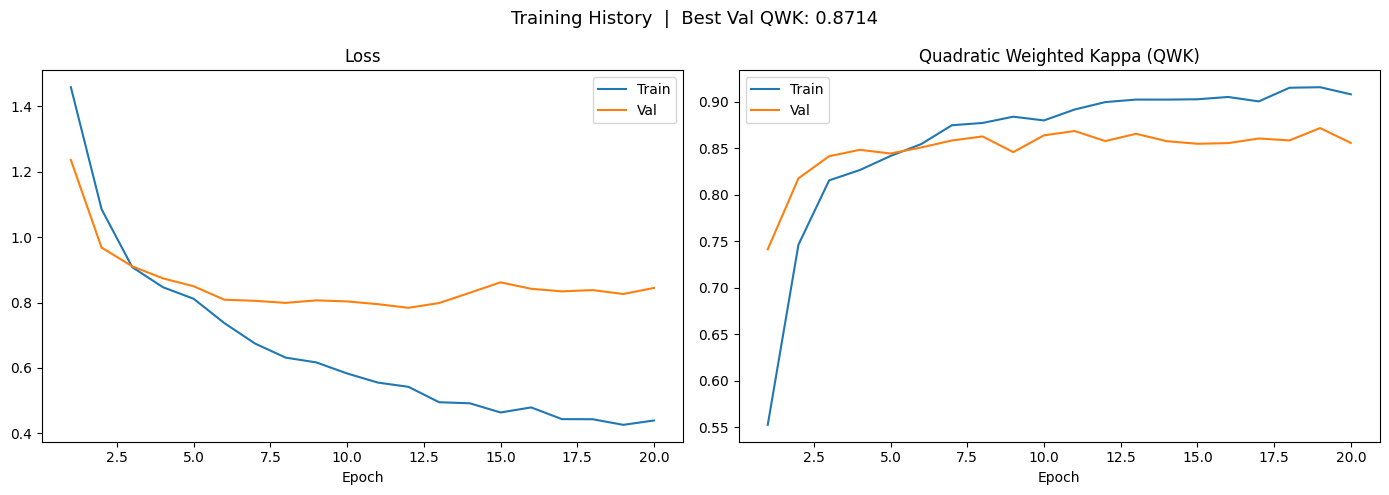


Best Validation QWK: 0.8714


In [ ]:
scaler = torch.cuda.amp.GradScaler()  # mixed precision scaler

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():  # fp16 forward pass
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    return total_loss / len(loader), qwk


def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Val', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.cuda.amp.autocast():
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            total_loss += loss.item()
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    return total_loss / len(loader), qwk, all_preds, all_labels


history = {'train_loss': [], 'val_loss': [], 'train_qwk': [], 'val_qwk': []}
best_qwk = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_qwk = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_qwk, _, _ = val_epoch(model, valid_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_qwk'].append(train_qwk)
    history['val_qwk'].append(val_qwk)

    marker = ''
    if val_qwk > best_qwk:
        best_qwk = val_qwk
        torch.save(model.state_dict(), 'best_model.pth')
        marker = '  <- BEST'

    print(f"Epoch {epoch:02d} | loss {train_loss:.4f}/{val_loss:.4f} | QWK {train_qwk:.4f}/{val_qwk:.4f}{marker}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, NUM_EPOCHS + 1)
ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(epochs, history['train_qwk'], label='Train')
ax2.plot(epochs, history['val_qwk'], label='Val')
ax2.set_title('Quadratic Weighted Kappa (QWK)'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.suptitle(f'Training History  |  Best Val QWK: {best_qwk:.4f}', fontsize=13)
plt.tight_layout(); plt.show()
print(f"\nBest Validation QWK: {best_qwk:.4f}")

## 9. Evaluation

Val:   0%|          | 0/12 [00:00<?, ?it/s]

Final Validation QWK: 0.8714


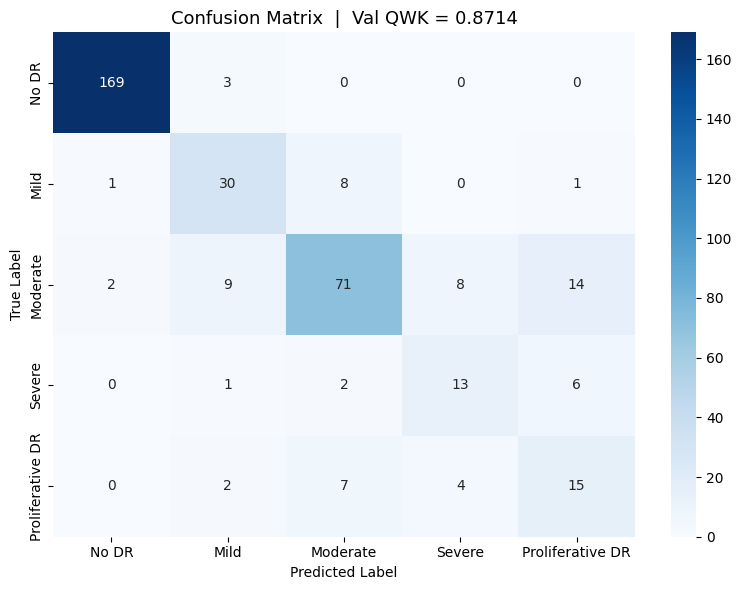


Per-class accuracy:
  Class 0 (No DR               ): 0.983  (172 samples)
  Class 1 (Mild                ): 0.750  (40 samples)
  Class 2 (Moderate            ): 0.683  (104 samples)
  Class 3 (Severe              ): 0.591  (22 samples)
  Class 4 (Proliferative DR    ): 0.536  (28 samples)


In [ ]:
model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
_, val_qwk, preds, labels = val_epoch(model, valid_loader, criterion, DEVICE)

print(f"Final Validation QWK: {val_qwk:.4f}")

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[LABELS[i] for i in range(5)],
            yticklabels=[LABELS[i] for i in range(5)], ax=ax)
ax.set_title(f'Confusion Matrix  |  Val QWK = {val_qwk:.4f}', fontsize=13)
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout(); plt.show()

preds_arr, labels_arr = np.array(preds), np.array(labels)
print("\nPer-class accuracy:")
for cls in range(5):
    mask = labels_arr == cls
    if mask.sum() > 0:
        acc = (preds_arr[mask] == cls).mean()
        print(f"  Class {cls} ({LABELS[cls]:20s}): {acc:.3f}  ({mask.sum()} samples)")

## 10. Inference Demo

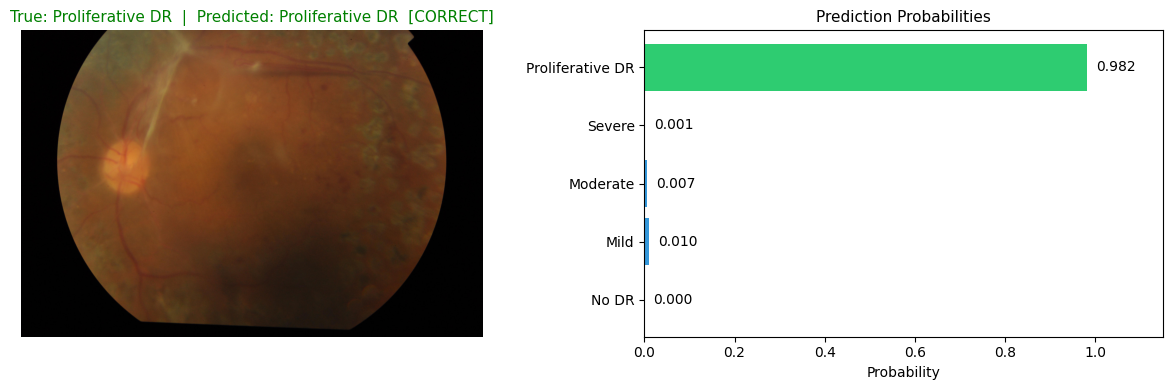


Image: 0981195eb9fb
True label:      4 - Proliferative DR
Predicted label: 4 - Proliferative DR
Confidence:      98.2%


In [ ]:
def predict_single(image_path, model, transform, device):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = crop_black_borders(img)
    img = apply_ben_graham(img)
    tensor = transform(image=img)['image'].unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).cpu().numpy()[0]
    return int(probs.argmax()), probs


sample_row = valid_df.sample(10, random_state=42).iloc[9]
img_id = sample_row['id_code']
true_label = int(sample_row['diagnosis'])

path = None
for ext in [IMG_EXT, '.png', '.jpg', '.jpeg']:
    candidate = f'{valid_img_dir}/{img_id}{ext}'
    if os.path.exists(candidate):
        path = candidate
        break

pred_class, probs = predict_single(path, model, val_transform, DEVICE)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(Image.open(path))
match = "CORRECT" if pred_class == true_label else "WRONG"
ax1.set_title(f'True: {LABELS[true_label]}  |  Predicted: {LABELS[pred_class]}  [{match}]',
              fontsize=11, color='green' if pred_class == true_label else 'red')
ax1.axis('off')

colors = ['#2ecc71' if i == pred_class else '#3498db' for i in range(5)]
bars = ax2.barh([LABELS[i] for i in range(5)], probs, color=colors)
ax2.set_xlim(0, 1.15)
ax2.set_title('Prediction Probabilities', fontsize=11)
ax2.set_xlabel('Probability')
for bar, p in zip(bars, probs):
    ax2.text(p + 0.02, bar.get_y() + bar.get_height()/2, f'{p:.3f}', va='center')
plt.tight_layout(); plt.show()

print(f"\nImage: {img_id}")
print(f"True label:      {true_label} - {LABELS[true_label]}")
print(f"Predicted label: {pred_class} - {LABELS[pred_class]}")
print(f"Confidence:      {probs[pred_class]:.1%}")